In [ ]:
#(TASK 3 CUSTOMER_CHURN_PREDICTION)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('Churn_Modelling.csv')

# Display the first 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head())

# Display dataset details and look for missing values
print("\n--- DATASET INFO ---")
df.info()

--- FIRST 5 ROWS ---


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [3]:
# Check target class distribution
print("Target Class Distribution (Counts):")
print(df['Exited'].value_counts())

print("\nTarget Class Distribution (Percentages):")
print(df['Exited'].value_counts(normalize=True) * 100)

# Quick look at categorical variable distributions
print("\nGeography Value Counts:")
print(df['Geography'].value_counts())

print("\nGender Value Counts:")
print(df['Gender'].value_counts())

Target Class Distribution (Counts):
Exited
0    7963
1    2037
Name: count, dtype: int64

Target Class Distribution (Percentages):
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

Geography Value Counts:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender Value Counts:
Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [4]:
# Separate features and target
X = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y = df['Exited']

# Stratified split to keep target ratio consistent
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Group features by type
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']

# Build ColumnTransformer for automated preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough' # Leaves binary columns like HasCrCard and IsActiveMember unchanged
)

print("Data preprocessing pipeline and splits are configured.")

Data preprocessing pipeline and splits are configured.


In [5]:
# Define and train the Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', LogisticRegression(random_state=42, max_iter=1000))])
lr_pipeline.fit(X_train, y_train)

# Evaluate performance
lr_preds = lr_pipeline.predict(X_test)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, lr_probs):.4f}\n")
print(classification_report(y_test, lr_preds))

=== Logistic Regression Results ===
Accuracy: 0.8080
ROC AUC Score: 0.7748

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [6]:
# Define and train the Random Forest pipeline
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', RandomForestClassifier(random_state=42, n_estimators=100))])
rf_pipeline.fit(X_train, y_train)

# Evaluate performance
rf_preds = rf_pipeline.predict(X_test)
rf_probs = rf_pipeline.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, rf_probs):.4f}\n")
print(classification_report(y_test, rf_preds))

=== Random Forest Results ===
Accuracy: 0.8610
ROC AUC Score: 0.8490

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [7]:
# Define and train the Gradient Boosting pipeline
gb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', GradientBoostingClassifier(random_state=42))])
gb_pipeline.fit(X_train, y_train)

# Evaluate performance
gb_preds = gb_pipeline.predict(X_test)
gb_probs = gb_pipeline.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting Results ===")
print(f"Accuracy: {accuracy_score(y_test, gb_preds):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, gb_probs):.4f}\n")
print(classification_report(y_test, gb_preds))

=== Gradient Boosting Results ===
Accuracy: 0.8700
ROC AUC Score: 0.8708

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



Feature importance graph successfully exported as 'churn_feature_importance.png'!


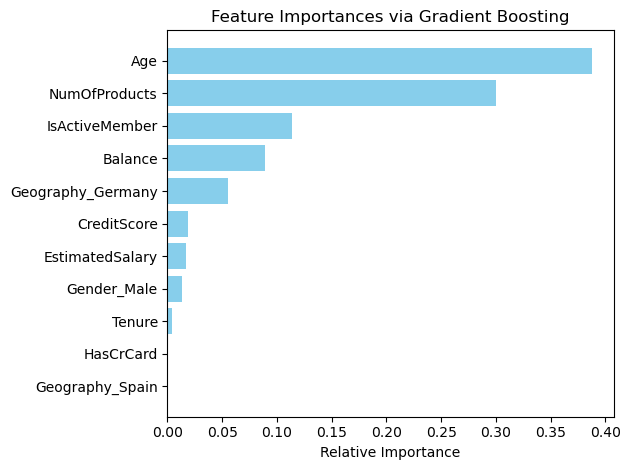

In [8]:
# Retrieve feature names from encoder step
cat_encoder = gb_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()

# Combine all feature names in exact order of transformation
all_features = numeric_features + encoded_cat_features + ['HasCrCard', 'IsActiveMember']

# Extract feature importances
importances = gb_pipeline.named_steps['model'].feature_importances_
indices = np.argsort(importances)

# Plotting the feature importances
plt.clf()
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [all_features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Feature Importances via Gradient Boosting')
plt.tight_layout()
plt.savefig('churn_feature_importance.png')
print("Feature importance graph successfully exported as 'churn_feature_importance.png'!")